2026-01-15 14-14-16
Outputs will be written to: results/run_2026-01-15 14-14-16
Saved a copy of the config : results/run_2026-01-15 14-14-16/config_copy.yaml
Inputs shape: (21, 2)
Outputs shape: (21,)
First 20 rows of raw data:
    cont-src-1  cont-src-2  radiation-reading   source
2     0.731024    0.733000       7.710875e-16     file
7     0.683418    0.861057       2.535001e-40     file
1     0.574329    0.879898       1.033078e-46     file
9     0.883890    0.582254       6.229856e-48     file
0     0.319404    0.762959       1.322677e-79     file
8     0.082507    0.403488       3.606771e-81     file
3     0.840353    0.264732      3.341771e-124     file
12    0.579291    1.059596      4.507438e-133   week-3
19    0.950054    1.057414     -5.419659e-201  week-10
20    1.043352    0.949466     -8.986546e-192  week-11
15    0.472352    1.055087     -1.802279e-144   week-6
16    0.523861    1.067166     -1.315157e-142   week-7
14    0.469395    1.050091     -6.688485e-142   week-5
11

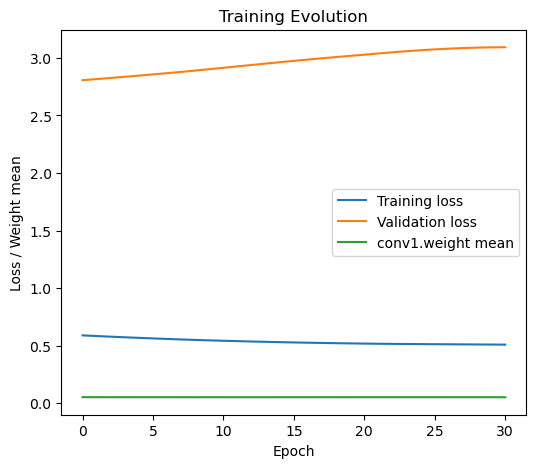

/opt/anaconda3/envs/tf-macos/lib/python3.10/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
sample_strategy=sobol, Final sample shape: (500000, 2)
Auto‑tuned percentile: 20%, threshold: 1.9746
Filtered 100000 candidates using filter_strategy='boundary'


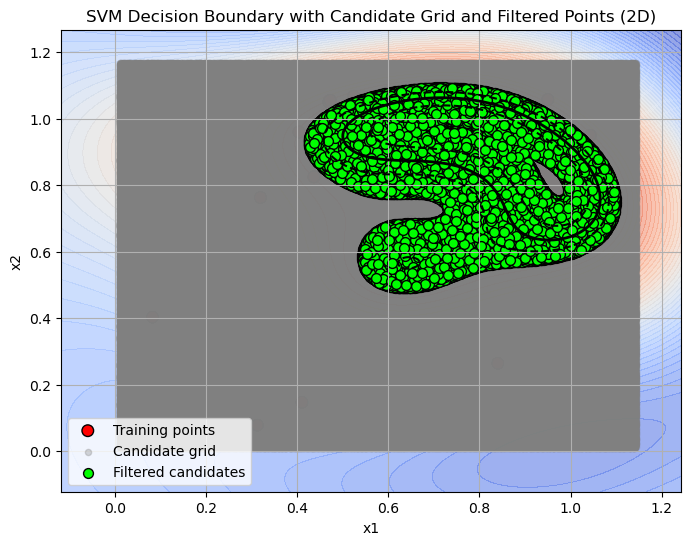

Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.0, 'kappa': None, 'x': array([1.0949575 , 0.70902105]), 'score': 0.04157647249902772, 'dim': 2, 'predicted_y': -0.00049570895, 'improvement_over_input_model': -4.540512e-05, 'distance_to_best_input': 0.4387250741761501}
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([1.0949575 , 0.70902105]), 'score': 0.038086080698081844, 'dim': 2, 'predicted_y': -0.00049570895, 'improvement_over_input_model': -4.540512e-05, 'distance_to_best_input': 0.4387250741761501}
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([1.0949575 , 0.70902105]), 'score': 0.016205147980703577, 'dim': 2, 'predicted_y': -0.00049570895, 'improvement_over_input_model': -4.540512e-05, 'distance_to_best_input': 0.4387250741761501}
{'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([1.0949575 , 0.70902105]), 'score': 0.00415133034464827, 'dim': 2, 'predicted_y': -0.00049570895, 'improvement_over_input_model': -4.540512e-05, 'distance_to_best_input':

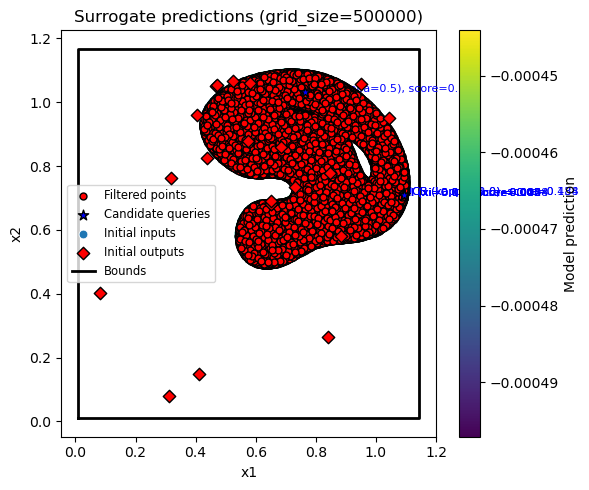

Saved dataframe to: results/run_2026-01-15 14-14-16/df_grid_500000_stride2_gp_max_raw_lr0.001_ep500.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 2.0, 'x': array([1.0949575 , 0.70902105]), 'score': 0.4338609713540567, 'dim': 2, 'predicted_y': -0.00049570895, 'improvement_over_input_model': -4.540512e-05, 'distance_to_best_input': 0.4387250741761501, 'best_input_x': array([0.68341817, 0.86105746]), 'best_input_pred': -0.00045030384}
    cont-src-1  cont-src-2  radiation-reading   source  radiation-reading-scaled
0     1.094957    0.709021       4.338610e-01   week-x              1.000000e+01
1     1.094957    0.709021       1.879405e-01   week-x              4.331813e+00
2     0.764957    1.030454       6.531071e-02   week-x              1.505337e+00
3     1.094957    0.709021       4.157647e-02   week-x              9.582902e-01
4     1.094957    0.709021       3.808608e-02   week-x              8.778407e-01
5     1.094957    0.709021       1.620515e-02   week-x           

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, setup_results_logging, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# set up logging to file
out_dir = setup_results_logging(cfg)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh, out_dir=out_dir)

print("Pipeline finished. Results keys:", list(results.keys()))